# Deep Reinforcement Learning - Assignment 1
## Part 1: Multi-Armed Bandit (MAB)

**Group Number:** 164

### Problem
Adaptive Treatment Recommendation System using Multi-Armed Bandit Learning

In [202]:
# Imports
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import datetime
import socket
import platform

In [203]:
# =====================================================
# Machine Information
# =====================================================

print("=" * 60)
print("Execution Timestamp :", datetime.datetime.now())
print("Machine Name        :", socket.gethostname())
print("Platform            :", platform.platform())
print("=" * 60)

Execution Timestamp : 2026-06-03 19:24:53.534459
Machine Name        : Rahuls-Macbook.local
Platform            : macOS-26.5-arm64-arm-64bit-Mach-O


# DataSet Design

In [204]:
# =====================================================
# Group Configuration
# =====================================================

# Group Number
G = 164

random.seed(G)
np.random.seed(G)

# Number of medicines
# 𝐾 = (𝐺 𝑚𝑜𝑑 3) + 5
K = (G % 3) + 5

# Hidden Success Probabilities
# 𝑃𝑖 = 0.4 + ((𝐺 + 𝑖) 𝑚𝑜𝑑 6) × 0.07
hidden_probabilities = []

for i in range(K):
    p = 0.4 + (((G + i) % 6) * 0.07)
    hidden_probabilities.append(round(p, 2))

print("\nGroup Number =", G)
print("Total Medicines =", K)

print("\nHidden Success Probabilities")
for i, p in enumerate(hidden_probabilities):
    print(f"Medicine {i} --> {p}")


Group Number = 164
Total Medicines = 7

Hidden Success Probabilities
Medicine 0 --> 0.54
Medicine 1 --> 0.61
Medicine 2 --> 0.68
Medicine 3 --> 0.75
Medicine 4 --> 0.4
Medicine 5 --> 0.47
Medicine 6 --> 0.54


In [205]:
# =====================================================
# Dataset Creation
# =====================================================

patients = []

for patient_id in range(1000):
    #𝑆𝑒𝑣𝑒𝑟𝑖𝑡𝑦 = (𝑝𝑎𝑡𝑖𝑒𝑛𝑡_𝑖𝑑 𝑚𝑜𝑑 5) + 1
    severity = (patient_id % 5) + 1

    # Dataset Schema
    # assigned_medicine, clinical_outcome, utility_score will be filled by each algo
    patients.append(
        {
            "patient_id": patient_id,  # Pateint Id
            "severity_score": severity,  # Disease Severity
            "assigned_medicine": None,  # medicine selected by algorithm
            "clinical_outcome": None,  # binary recovery (0/1)
            "utility_score": None  # final reward
        }
    )

dataset = pd.DataFrame(patients)

print("\nFirst 10 Rows")
dataset.head(10)


First 10 Rows


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
0,0,1,None,None,None
1,1,2,None,None,None
2,2,3,None,None,None
3,3,4,None,None,None
4,4,5,None,None,None
5,5,1,None,None,None
6,6,2,None,None,None
7,7,3,None,None,None
8,8,4,None,None,None
9,9,5,None,None,None


In [206]:
# ---------------------------------------------------
# Reward Function
# ---------------------------------------------------

def get_reward(medicine, severity):
    """
    Calculates Clinical Outcome and Utility Score(Reward) based on medicines hidden probability and patient severity
    :param medicine: Medicine ID
    :param severity: Severity score calculated for patient
    :return: Clinical Outcome and Utility Score(Reward) based on medicines hidden probability and patient severity
    """

    # Based on hidden probibilities 1 or 0
    clinical_outcome = np.random.binomial(1, hidden_probabilities[medicine])

    # 𝑈𝑡𝑖𝑙𝑖𝑡𝑦𝑆𝑐𝑜𝑟𝑒 = 𝑐𝑙𝑖𝑛𝑖𝑐𝑎𝑙_𝑢𝑡𝑐𝑜𝑚𝑒 × (1 −𝑆𝑒𝑣𝑒𝑟𝑖𝑡𝑦/10 )
    # If patient recovers and severity = 1 → reward = 0.9
    # If patient recovers and severity = 5 → reward = 0.5
    # If patient does not recover → reward = 0
    utility_score = clinical_outcome * (1 - severity / 10)

    return clinical_outcome, utility_score

In [207]:
# ---------------------------------------------------
# Immediate Exploitation
# ---------------------------------------------------
def immediate_exploitation():
    """
    Implements the Immediate Exploitation strategy.
    Each medicine is tested exactly 10 times.
    After the initial testing phase, the medicine with the
    highest observed success rate is selected and used for
    all remaining patients.
    Returns:
    cumulative_rewards : list
        Running cumulative reward over 1000 patients.

    immediate_df : DataFrame
        Dataset containing assigned medicines,
        outcomes, and rewards.
    :return: cumulative_rewards, immediate_df
    """
    # Copy Dataset to new Dataframe
    immediate_df = dataset.copy()

    # K number of medicines
    # Initial Pulls and Zeros(Track Variables)
    # Pull means No of times the medicine i is used
    # Success means No of successfull recoveries for medicine i
    pulls = np.zeros(K)
    successes = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0

    # To keep track how many patients are already tracked
    patient = 0

    # Exploration Phase
    # Each medicine tested exactly 10 times initially(10*K patients), then continue using only the currently best-performing one
    for medicine in range(K):

        for _ in range(10):
            severity = immediate_df.loc[patient, "severity_score"]

            # Calculate reward and outcome for each medicine and patient i
            outcome, reward = get_reward(medicine, severity)

            # Updates values in data frame
            immediate_df.loc[patient, "assigned_medicine"] = medicine
            immediate_df.loc[patient, "clinical_outcome"] = outcome
            immediate_df.loc[patient, "utility_score"] = reward

            # Updates medicine used statistics
            pulls[medicine] += 1
            # Updates the successful recovery done for medicine based on outcome score for patient
            successes[medicine] += outcome

            # Calculate accumulated Rewards
            total_reward += reward
            cumulative_rewards.append(total_reward)

            patient += 1

    # Success rate for each medicine
    avg_success_rate = successes / pulls
    # Best medicine id based on highest success rate
    best_medicine = np.argmax(avg_success_rate)

    print("\nBest Medicine Selected:", best_medicine)

    # Exploitation Phase
    # As 10*K patients already used in Exploration Phase so only (1000 - 10*K) will be used now
    while patient < 1000:
        severity = immediate_df.loc[patient, "severity_score"]

        outcome, reward = get_reward(best_medicine, severity)

        immediate_df.loc[patient, "assigned_medicine"] = best_medicine
        immediate_df.loc[patient, "clinical_outcome"] = outcome
        immediate_df.loc[patient, "utility_score"] = reward

        # Only update usage and success count for best medicine now
        pulls[best_medicine] += 1
        successes[best_medicine] += outcome

        total_reward += reward
        cumulative_rewards.append(total_reward)

        patient += 1

    return cumulative_rewards, immediate_df

In [208]:
immediate_rewards, immediate_df = immediate_exploitation()

print("\nImmediate Exploitation Results: ")

print("\nFinal Reward :", round(immediate_rewards[-1], 2))

print("\nRandom 10 Patients Records")

immediate_df.sample(10, random_state=164).sort_values("patient_id")


Best Medicine Selected: 3

Immediate Exploitation Results: 

Final Reward : 520.0

Random 10 Patients Records


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
31,31,2,3,1,0.8
156,156,2,3,0,0.0
190,190,1,3,1,0.9
400,400,1,3,1,0.9
405,405,1,3,1,0.9
535,535,1,3,1,0.9
581,581,2,3,1,0.8
607,607,3,3,1,0.7
756,756,2,3,1,0.8
873,873,4,3,1,0.6


In [209]:
# ---------------------------------------------------
# Controlled Clinical Trial Strategy(Epsilon Based Greedy)
# ---------------------------------------------------
def controlled_clinical_trial(epsilon):
    """
    Implements the Controlled Clinical Trial(Epsilon-Greedy) strategy.
    Returns Cumulative rewards and final dataframe of patients
    Follows suggestion "Most patients should receive the current best treatment, but occasionally
    another treatment should be tested to discover hidden opportunities."
    :param epsilon: Probability of exploration.
    :return:
    """
    # Copy Initial Dataset to new Dataframe
    epsilon_df = dataset.copy()

    # Initial Pulls and Zeros(Track Variables)
    # Pull means No of times the medicine i is used
    # Success means No of successfull recoveries for medicine i
    pulls = np.ones(K)  # needed one as can get divide by zero in avg_success = successes / pulls
    successes = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0

    for patient in range(1000):

        severity = epsilon_df.loc[patient, "severity_score"]

        if np.random.random() < epsilon:
            # Exploration ( Random exploration based on epsilon value)
            # np.random.random() generates random number between 0.0 - 1.0 so based on selected epsilon exploration can be done
            #Selects random medicine to explore
            medicine = np.random.randint(K)
        else:
            # Exploitation
            # Success rate for each medicine
            avg_success = successes / pulls
            # Select best medicine after each patient iteration
            medicine = np.argmax(avg_success)

        # Calculate reward and outcome for each medicine and patient i
        outcome, reward = get_reward(medicine, severity)

        # Updates values in data frame
        epsilon_df.loc[patient, "assigned_medicine"] = medicine
        epsilon_df.loc[patient, "clinical_outcome"] = outcome
        epsilon_df.loc[patient, "utility_score"] = reward

        # update usage and success count for selected/best medicine
        pulls[medicine] += 1
        successes[medicine] += outcome

        # Calculate accumulated Rewards
        total_reward += reward
        cumulative_rewards.append(total_reward)

    return cumulative_rewards, epsilon_df

In [210]:
# Controlled Clinical Trial Strategy (10% Exploration)
eps_10, eps10_df = controlled_clinical_trial(0.10)
# Controlled Clinical Trial Strategy (1% Exploration)
eps_01, eps01_df = controlled_clinical_trial(0.01)
# Controlled Clinical Trial Strategy (50% Exploration)
eps_50, eps50_df = controlled_clinical_trial(0.50)

print("\nControlled Clinical Trial Strategy Results")

print("\n1% Exploration Rewards:", round(eps_01[-1], 2))
print("\n10% Exploration Rewards", round(eps_10[-1], 2))
print("\n50% Exploration Rewards:", round(eps_50[-1], 2))

print("\nRandom 10 Patients Records for 10% Exploration")

eps10_df.sample(10, random_state=164).sort_values("patient_id")




Controlled Clinical Trial Strategy Results

1% Exploration Rewards: 389.0

10% Exploration Rewards 472.4

50% Exploration Rewards: 463.9

Random 10 Patients Records for 10% Exploration


,patient_id,severity_score,assigned_medicine,clinical_outcome,utility_score
31,31,2,1,1,0.8
156,156,2,1,1,0.8
190,190,1,1,1,0.9
400,400,1,1,1,0.9
405,405,1,1,1,0.9
535,535,1,3,1,0.9
581,581,2,3,1,0.8
607,607,3,3,1,0.7
756,756,2,3,1,0.8
873,873,4,3,1,0.6


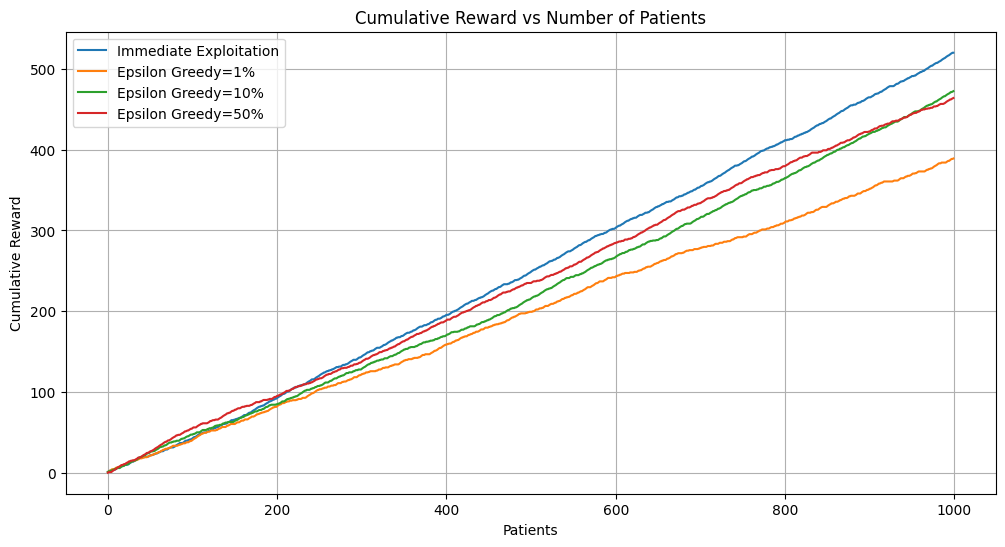

In [211]:
# ---------------------------------------------------
# Visual Comparative Analysis
# Cumulative Reward vs. Number of Patients
# ---------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(immediate_rewards, label="Immediate Exploitation")

plt.plot(eps_01, label="Epsilon Greedy=1%")

plt.plot(eps_10, label="Epsilon Greedy=10%")

plt.plot(eps_50, label="Epsilon Greedy=50%")

plt.xlabel("Patients")
plt.ylabel("Cumulative Reward")

plt.title("Cumulative Reward vs Number of Patients")

plt.grid(True)

plt.legend()

plt.show()

In [212]:
# ---------------------------------------------------
# Final Reward Statistics(All Strategies)
# ---------------------------------------------------
print("\nFinal Reward Statistics\n")
results = pd.DataFrame(
    {"Strategy": ["Immediate Exploitation", "Epsilon Greedy 1%", "Epsilon Greedy 10%", "Epsilon Greedy 50%"],
     "Final Reward": [immediate_rewards[-1], eps_01[-1], eps_10[-1], eps_50[-1]]
     })
print("="*50)
print(results.to_string(index=False))


Final Reward Statistics

              Strategy  Final Reward
Immediate Exploitation         520.0
     Epsilon Greedy 1%         389.0
    Epsilon Greedy 10%         472.4
    Epsilon Greedy 50%         463.9
